Misma idea que en `Comparacion_Boyas_UPCT_IMIDA_raw.ipynb` pero usando ya los dataframes procesados y con las fechas en las que hay también imagen de satélite.

In [66]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import re


In [67]:
# Cargamos los csv de los tifs
path = "saved_files/dataset/"
dfs = {}
for archivo in os.listdir(path):
    if archivo.endswith(".csv") and not archivo.endswith("_features.csv") and archivo.startswith("c2x-nets") :
        nombre_sin_extension = os.path.splitext(archivo)[0]  # sin .csv
        ruta_completa = os.path.join(path, archivo)
        dfs[nombre_sin_extension] = pd.read_csv(ruta_completa)

In [68]:
dates = set(dfs["c2x-nets_1x1_imida_depth_eq_0"]["Date"]).intersection(set(dfs["c2x-nets_1x1_upct_depth_eq_0"]["Date"]))

In [69]:
for nombre_df, df in dfs.items():
        dfs[nombre_df] = df.loc[df["Date"].isin(dates),:]

In [70]:
from collections import defaultdict
import re

# Supongamos que tu dict se llama `dict_dfs`
comparables = defaultdict(lambda: {'upct': None, 'imida': None})

for name, df in dfs.items():
    match = re.match(r'c2x-nets_(\d+x\d+)_(upct|imida)_depth_(.*)', name)
    if match:
        kernel, tipo, profundidad = match.groups()
        comparables[(kernel, profundidad)][tipo] = df


In [71]:
kernel = "3x3"
subconjunto = [
    (kernel, "lt_1"),
    (kernel, "eq_0"),
    (kernel, "eq_1"),
    (kernel, "lt_2"),
    (kernel, "gt_1"),
]

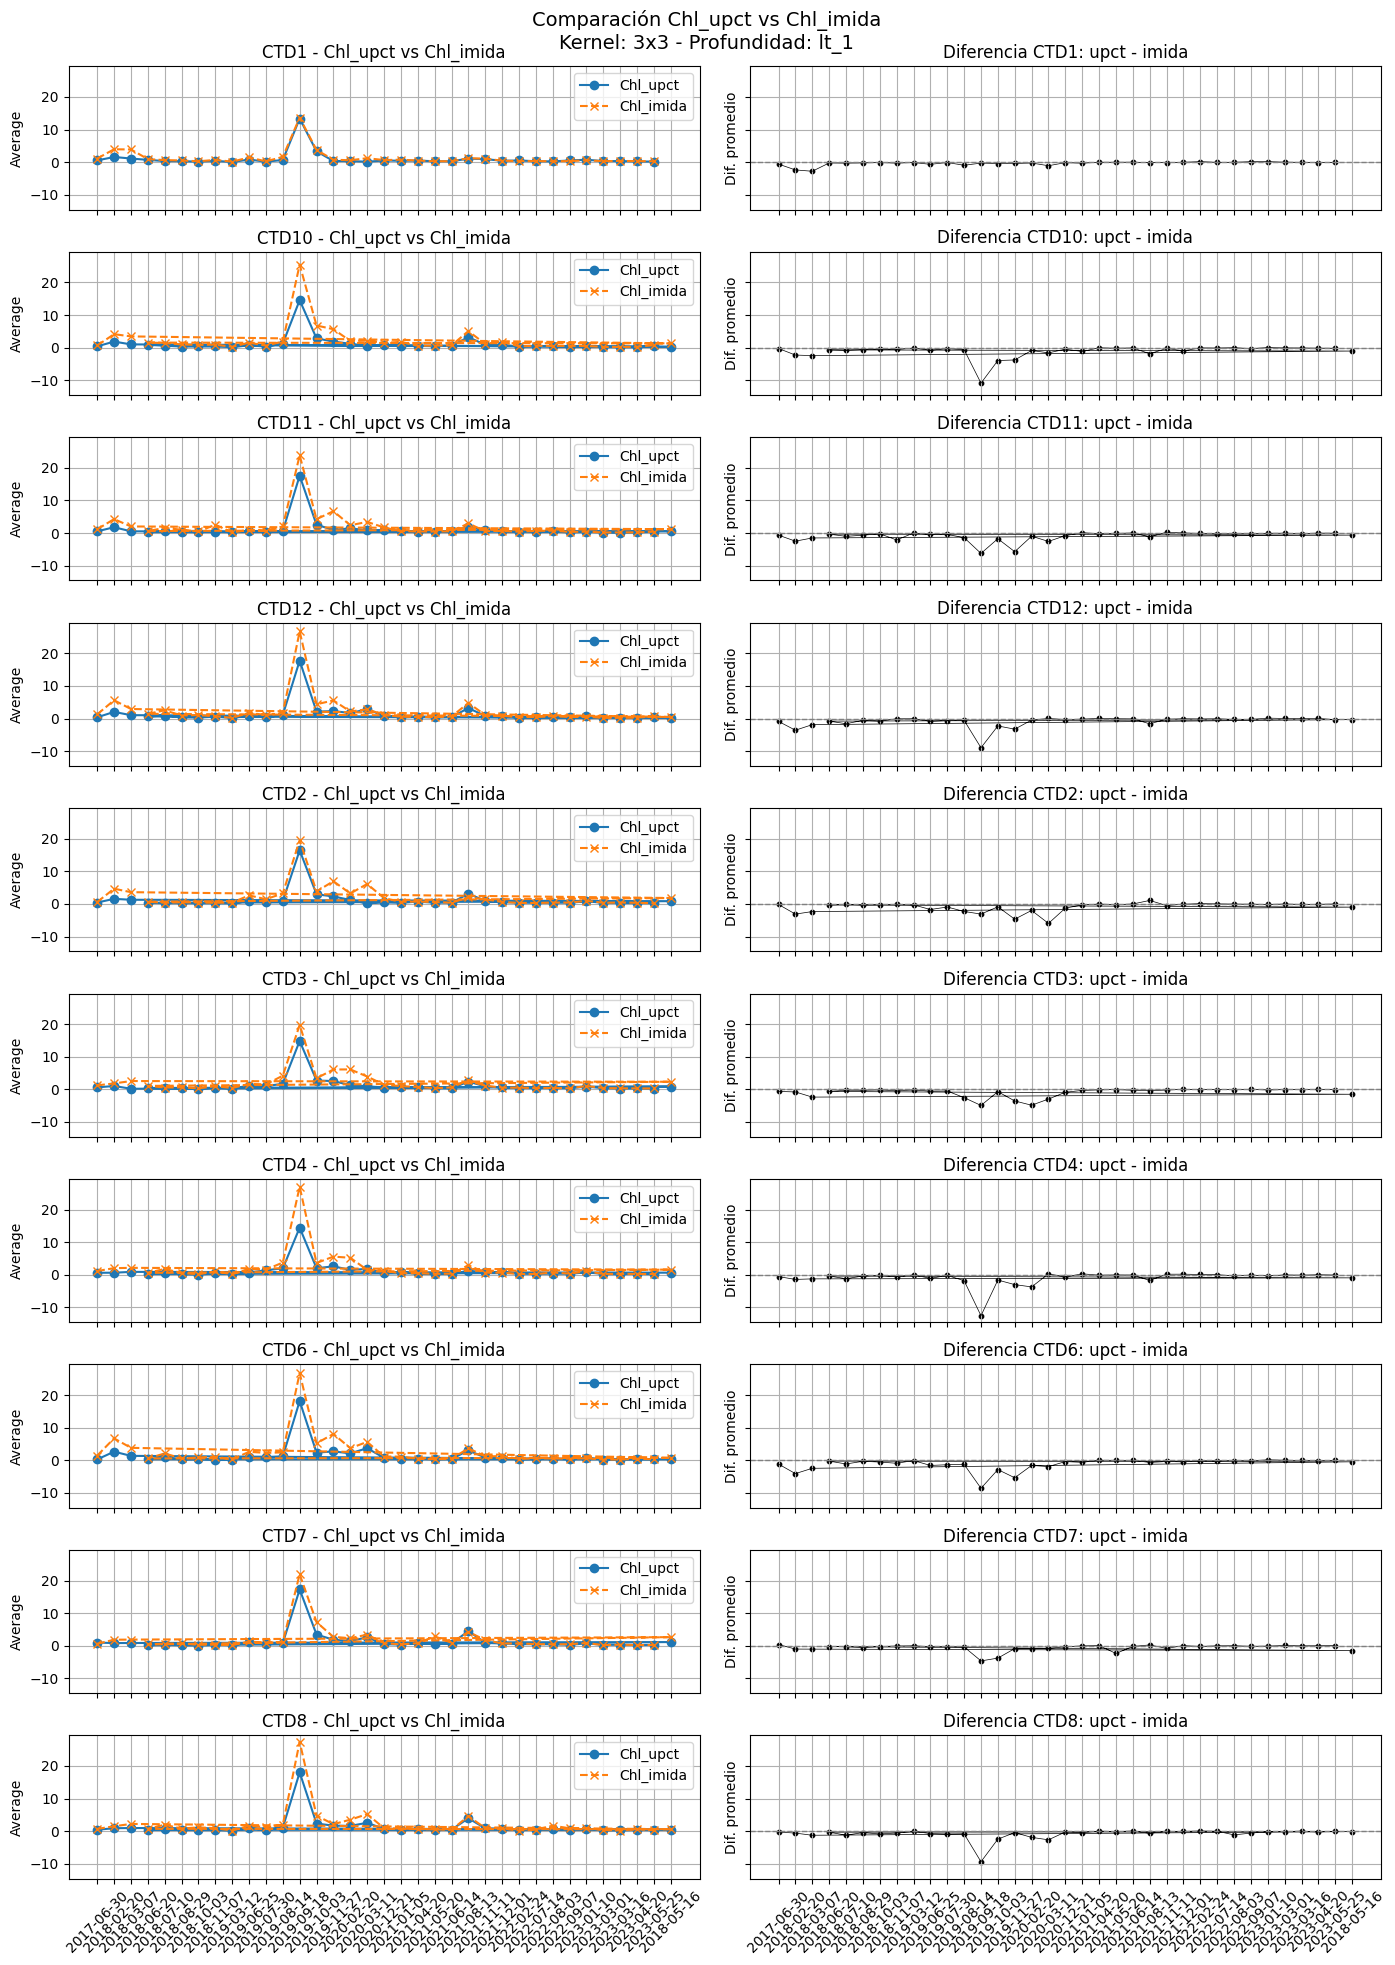

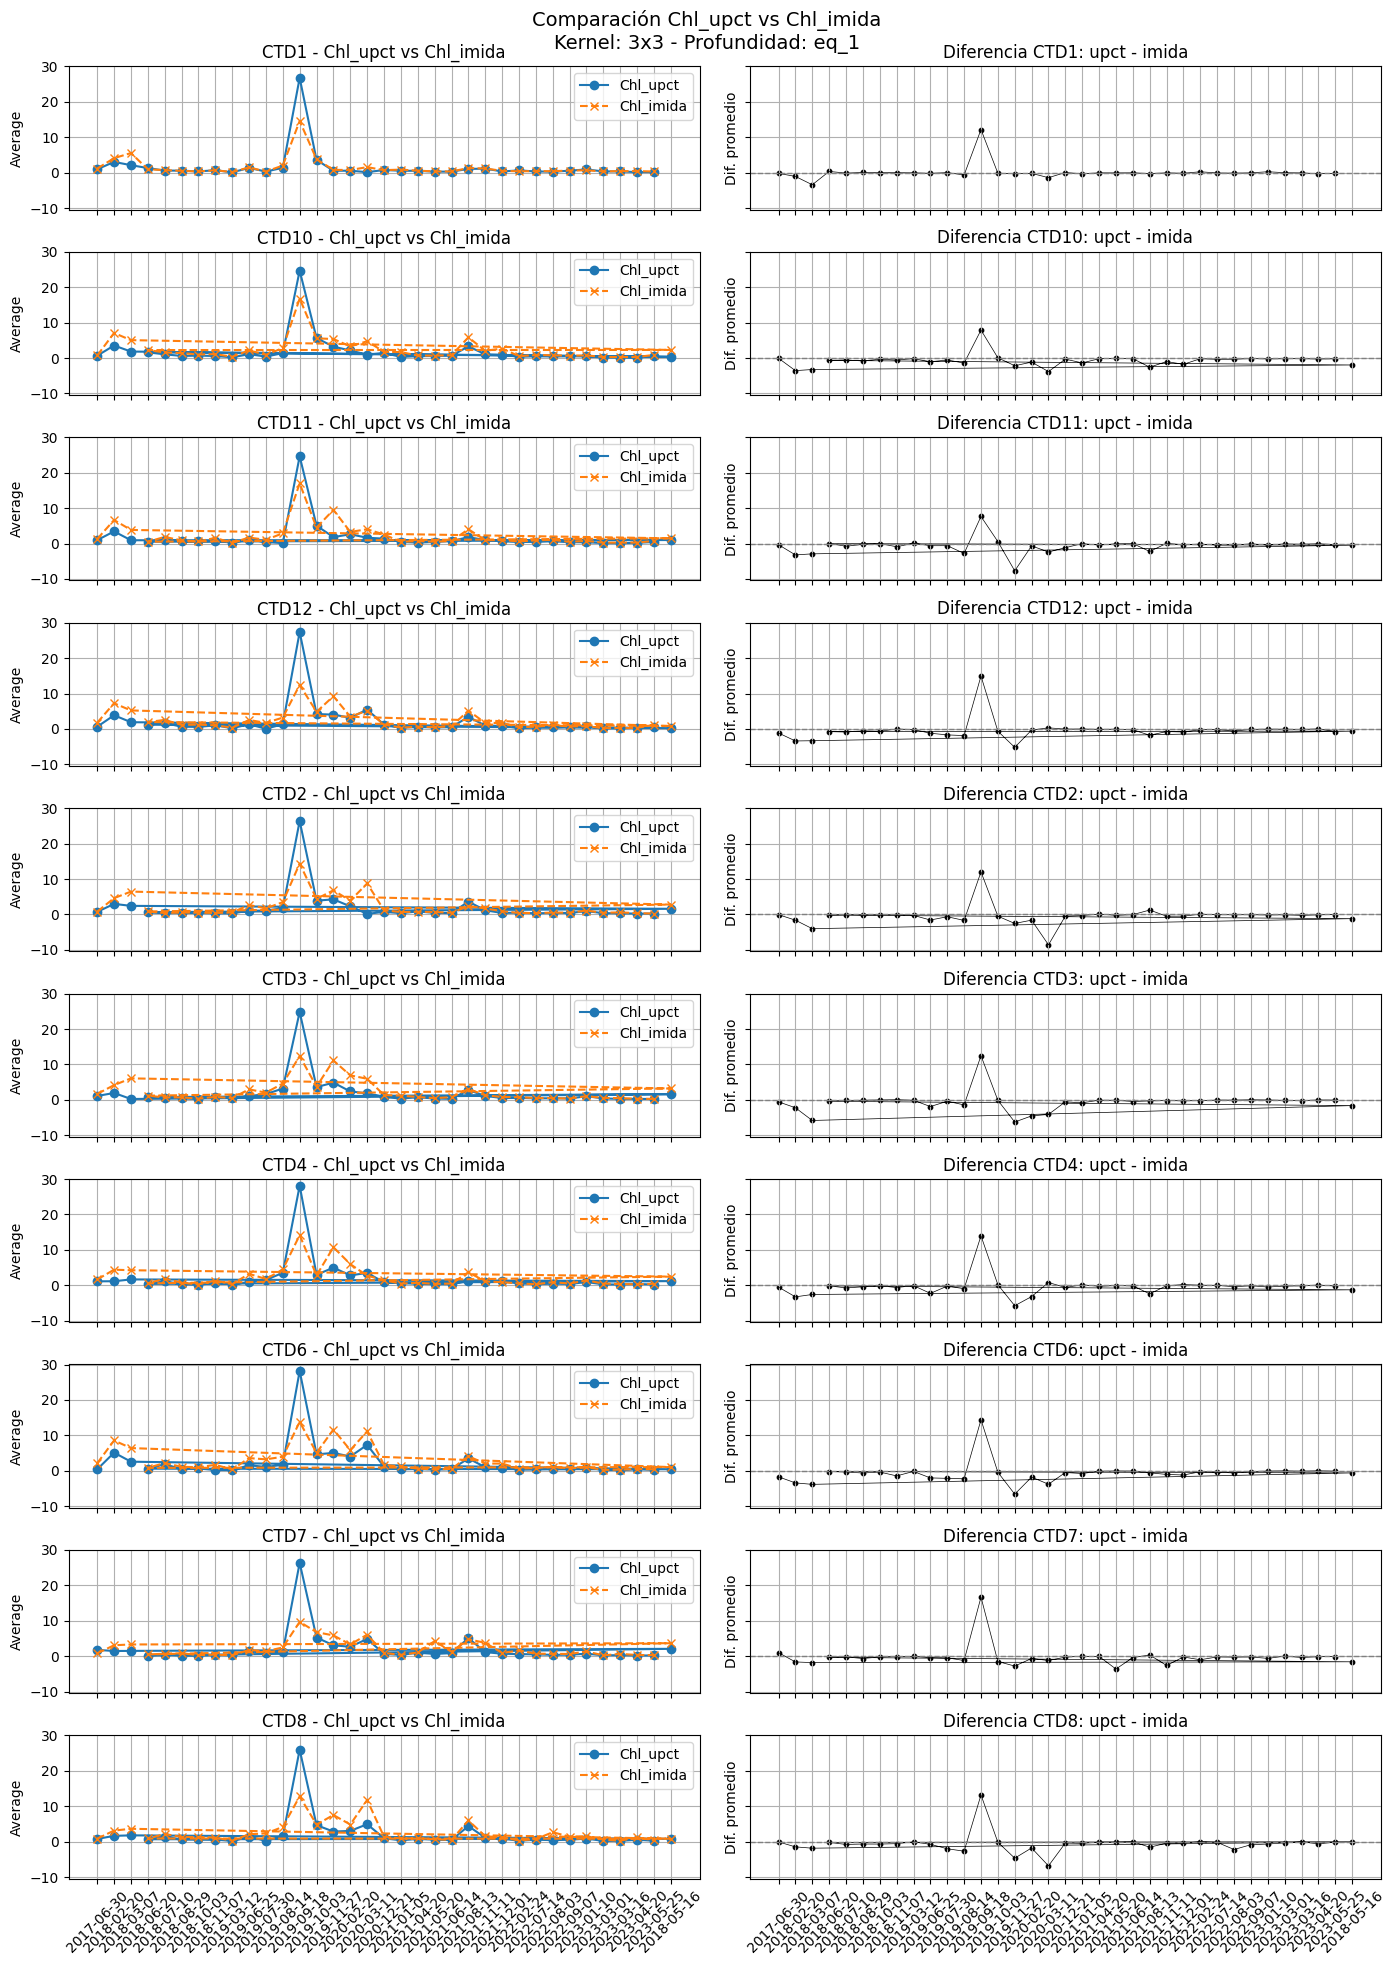

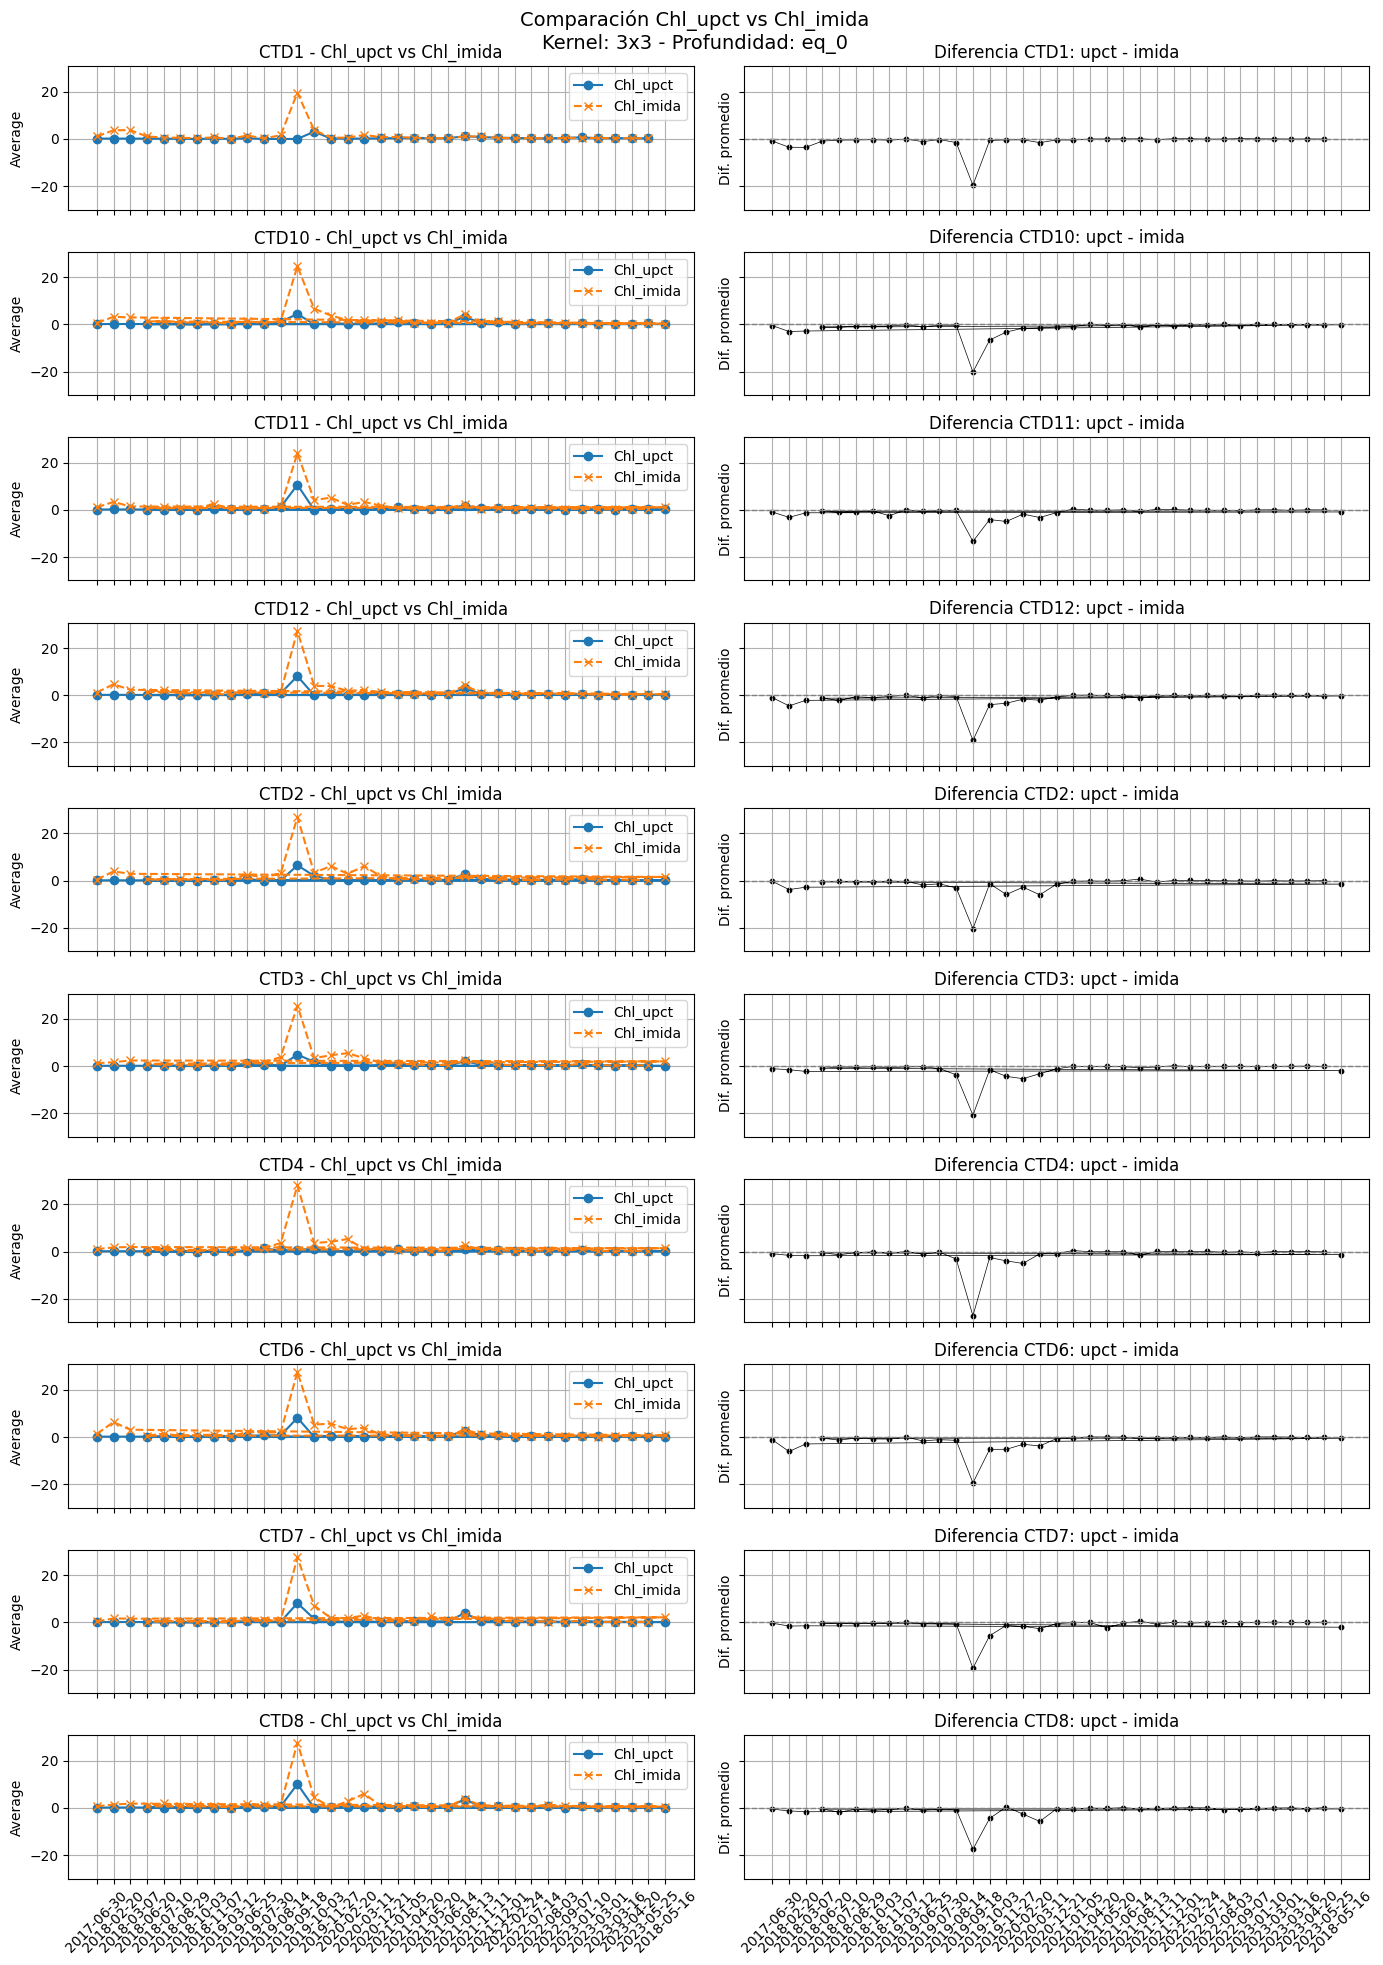

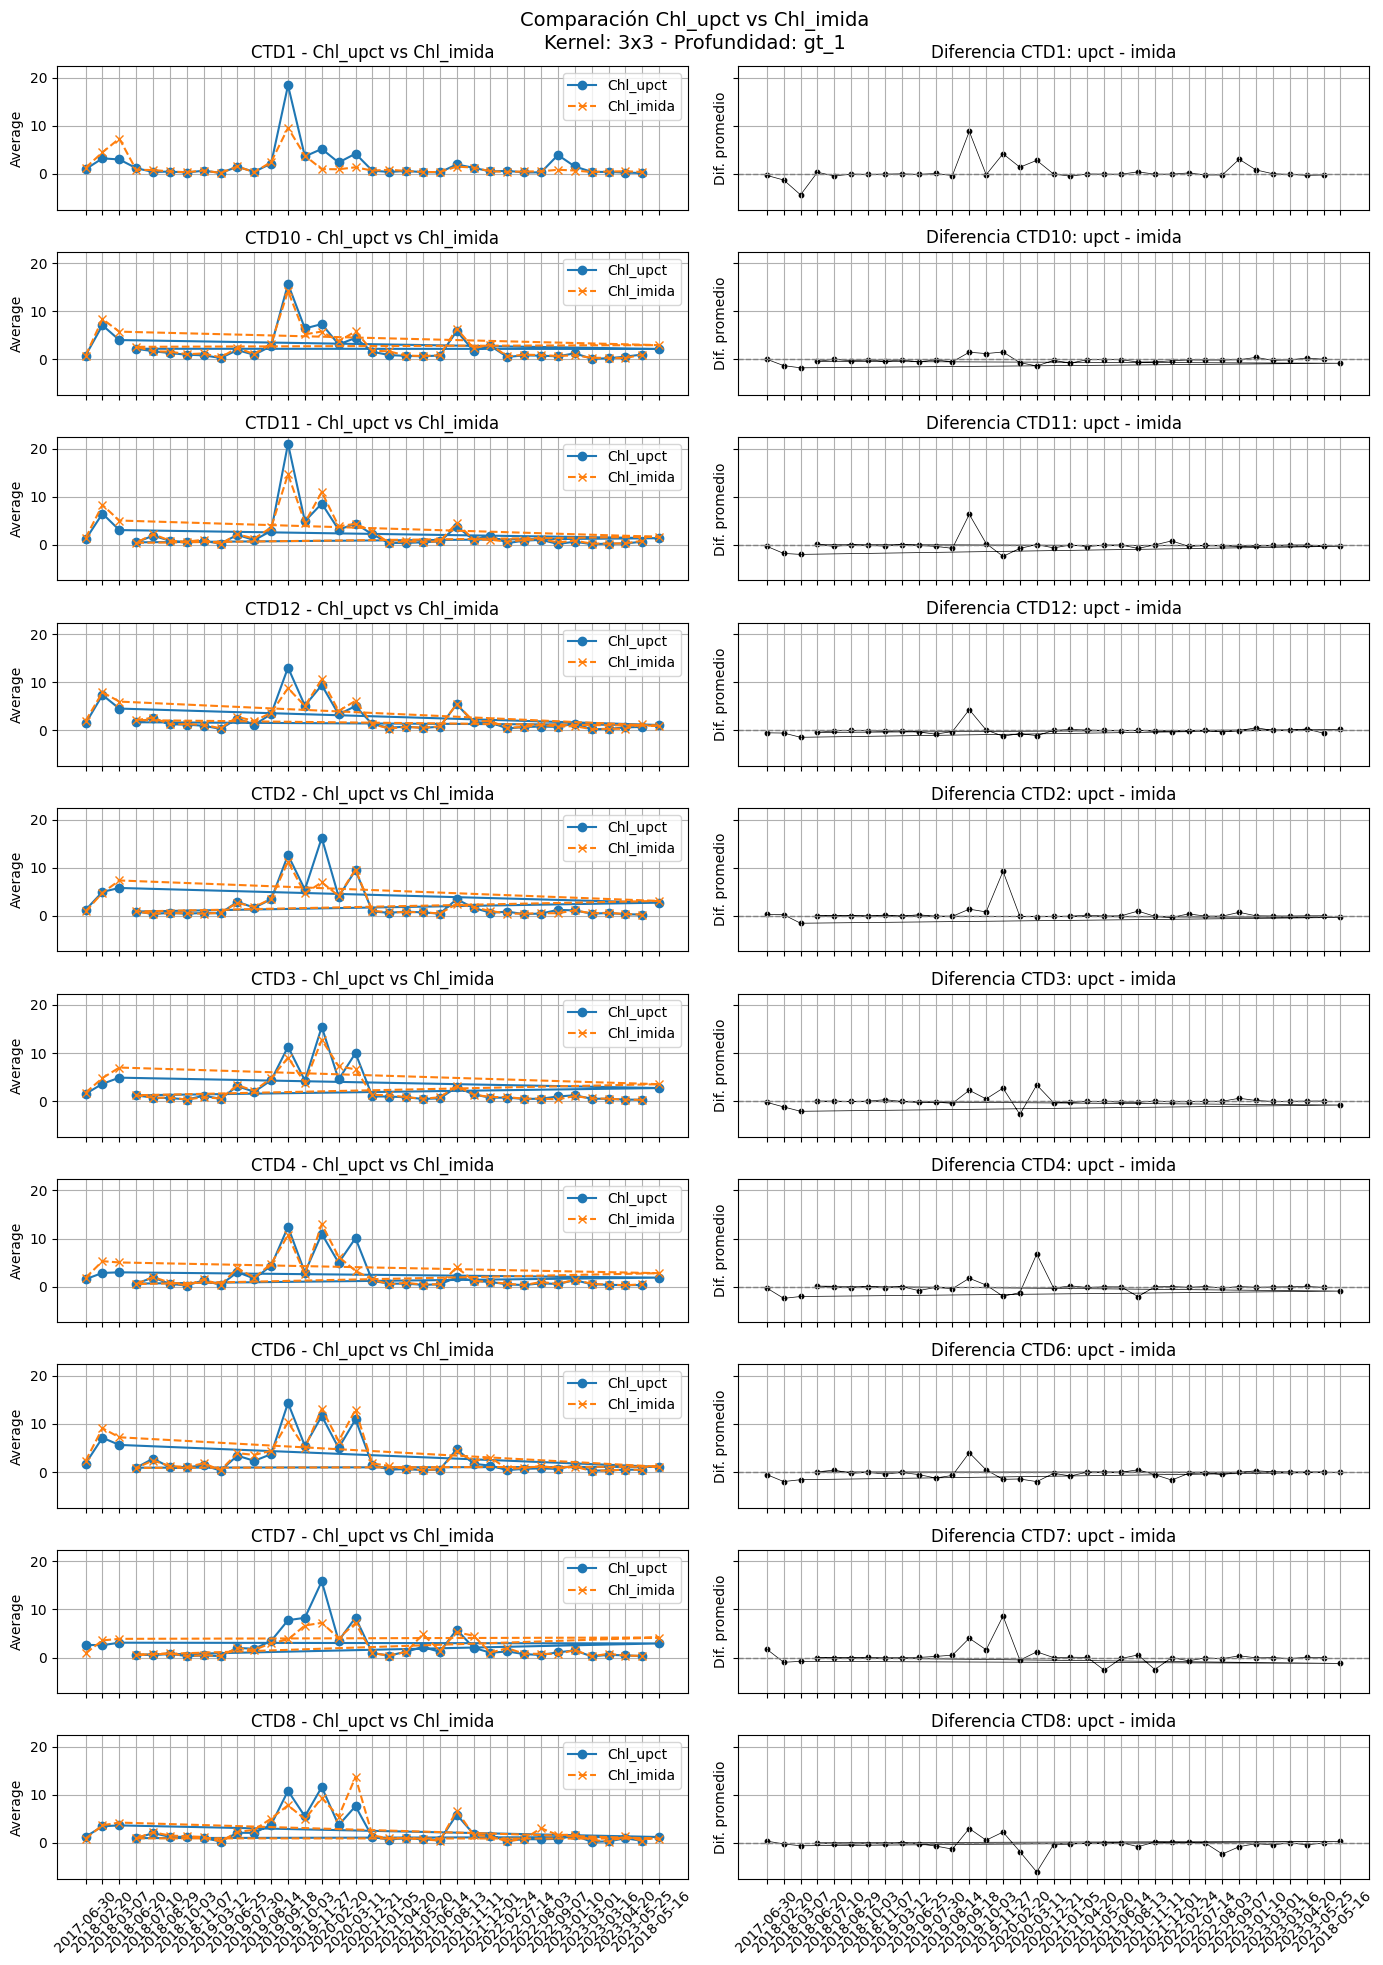

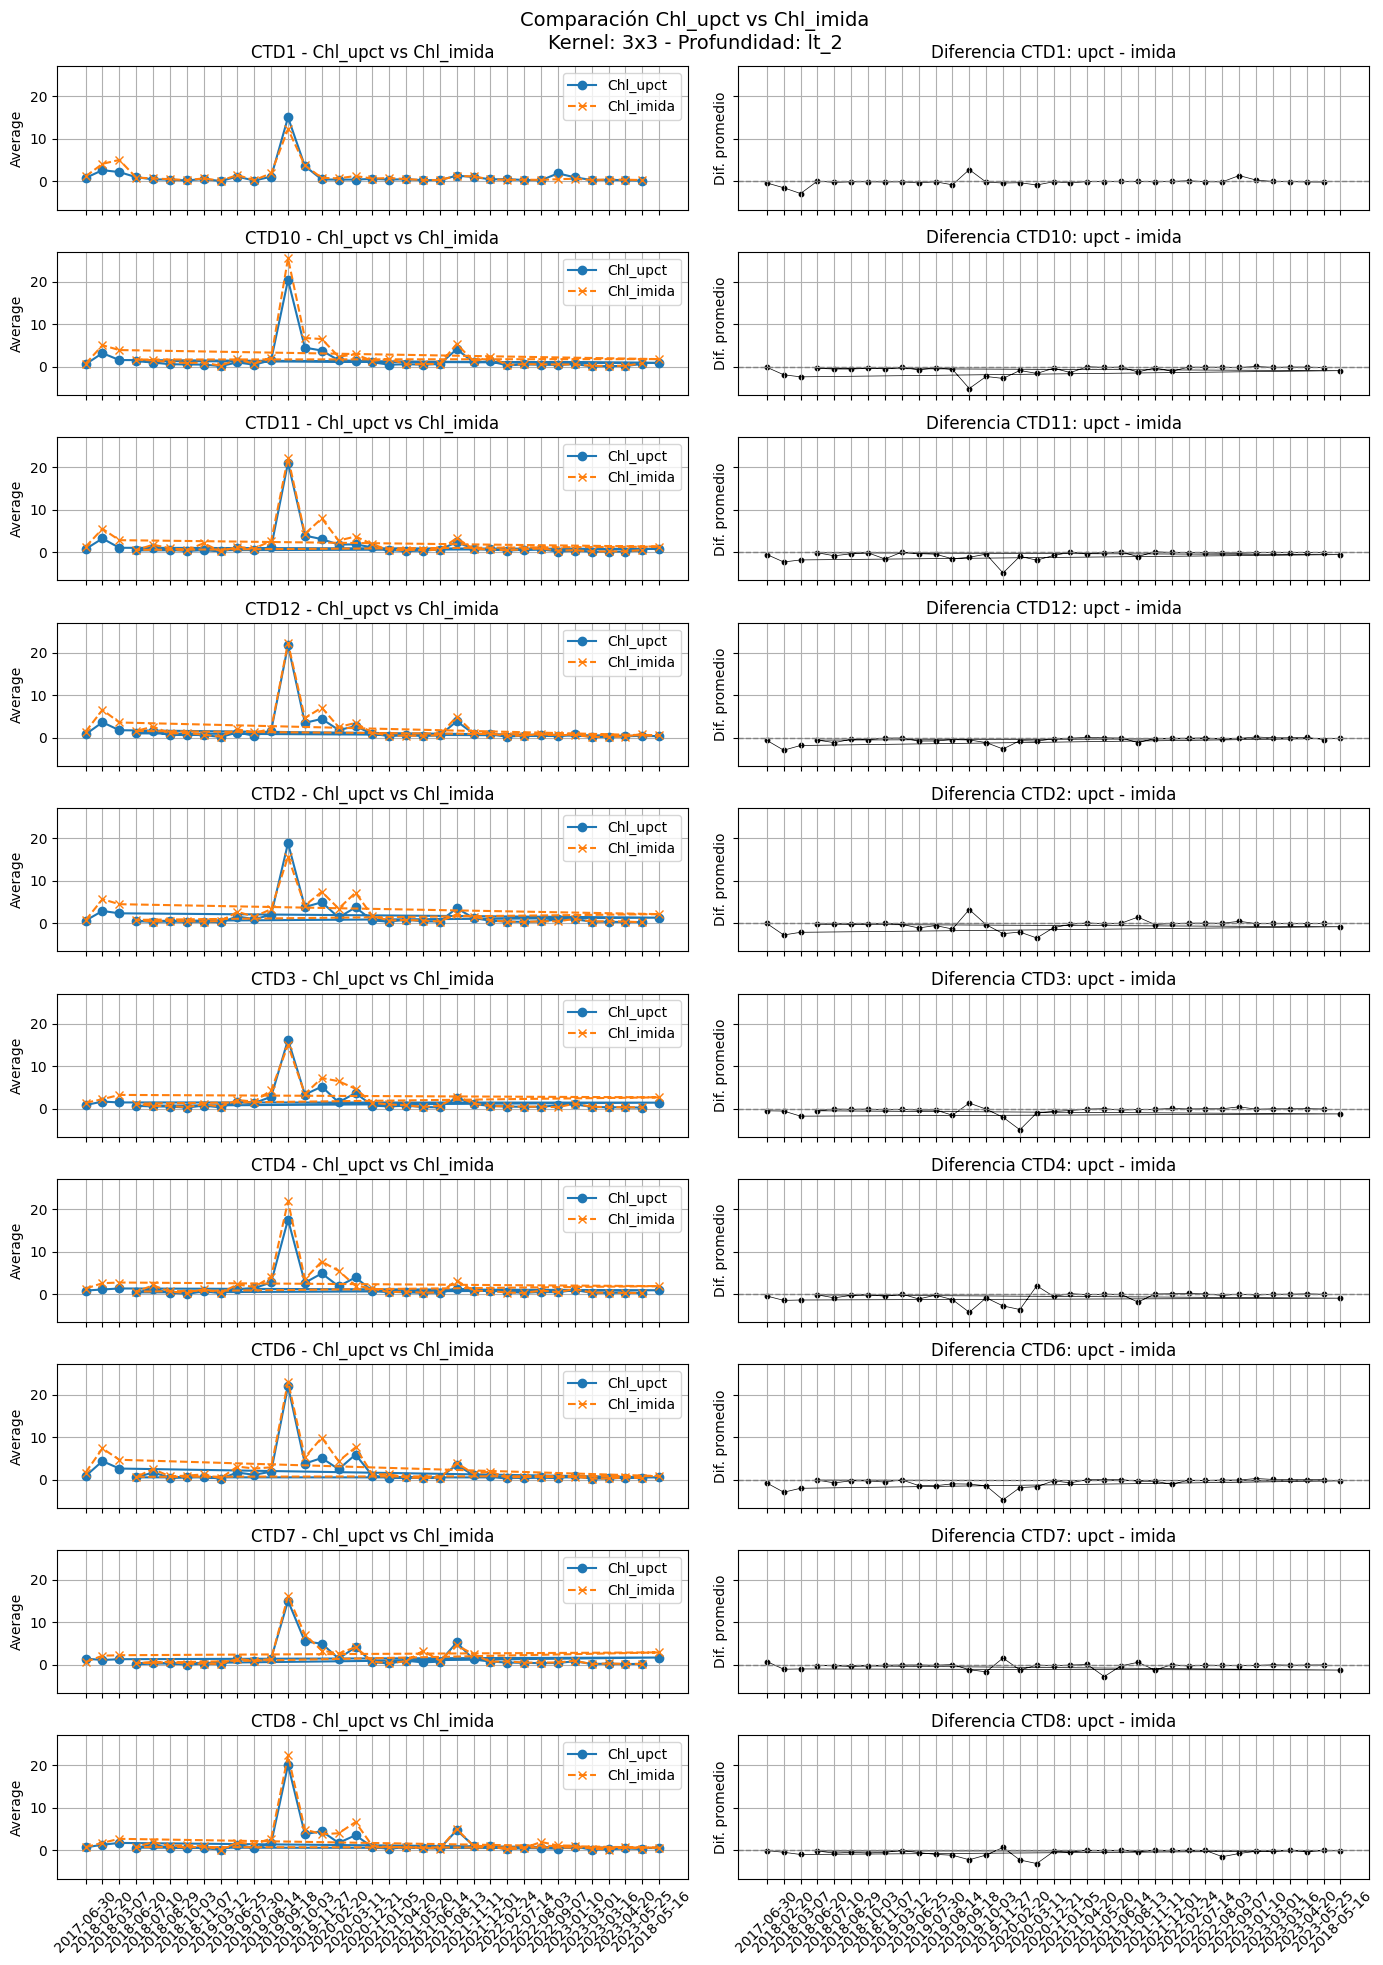

In [72]:
for (kernel, profundidad), tipos in comparables.items():

    if (kernel, profundidad) not in subconjunto:
        continue 
    df_upct = tipos['upct']
    df_imida = tipos['imida']

    if df_upct is not None and df_imida is not None:
        # Unificar fechas y boyas
        fechas_comunes = set(df_upct['Date']).intersection(df_imida['Date'])
        df_upct_filtrado = df_upct[df_upct['Date'].isin(fechas_comunes)]
        df_imida_filtrado = df_imida[df_imida['Date'].isin(fechas_comunes)]

        df_upct['Date'] = pd.to_datetime(df_upct['Date'])
        df_imida['Date'] = pd.to_datetime(df_imida['Date'])


        # Merge por Date y Buoy
        merged = pd.merge(
            df_upct_filtrado[['Date', 'Buoy', 'Chl']],
            df_imida_filtrado[['Date', 'Buoy', 'Chl']],
            on=['Date', 'Buoy'],
            suffixes=('_upct', '_imida')
        )

        merged = merged.sort_values(['Buoy', 'Date'])

        # Calcular diferencia
        merged['Chl_diff'] = merged['Chl_upct'] - merged['Chl_imida']

        buoys = merged['Buoy'].unique() #["CTD1", "CTD2", "CTD3"]#

        fig, axes = plt.subplots(len(buoys), 2, figsize=(14, 2 * len(buoys)), sharex='col', sharey=True)
        fig.suptitle(f"Comparación Chl_upct vs Chl_imida\nKernel: {kernel} - Profundidad: {profundidad}", fontsize=14)
        if len(buoys) == 1:
            axes = [axes]  # hacer iterable si solo hay una boya

        for i, buoy in enumerate(buoys):
            df_buoy = merged[merged['Buoy'] == buoy]

            # --- Panel izquierdo: las dos series ---
            axes[i][0].plot(df_buoy['Date'], df_buoy['Chl_upct'], label='Chl_upct', marker='o', linestyle='-')
            axes[i][0].plot(df_buoy['Date'], df_buoy['Chl_imida'], label='Chl_imida', marker='x', linestyle='--')
            axes[i][0].set_title(f"{buoy} - Chl_upct vs Chl_imida")
            axes[i][0].set_ylabel("Average")
            axes[i][0].grid(True)
            axes[i][0].legend()

            # --- Panel derecho: diferencia ---
            axes[i][1].scatter(df_buoy['Date'], df_buoy['Chl_diff'], color='black', s=10)
            axes[i][1].plot(df_buoy['Date'], df_buoy['Chl_diff'], color='black', linewidth=0.5)
            axes[i][1].axhline(0, color='gray', linestyle='--', linewidth=1)
            axes[i][1].set_title(f"Diferencia {buoy}: upct - imida")
            axes[i][1].set_ylabel("Dif. promedio")
            axes[i][1].grid(True)

            # Rotación de fechas para ambos paneles
            axes[i][0].tick_params(axis='x', rotation=45)
            axes[i][1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

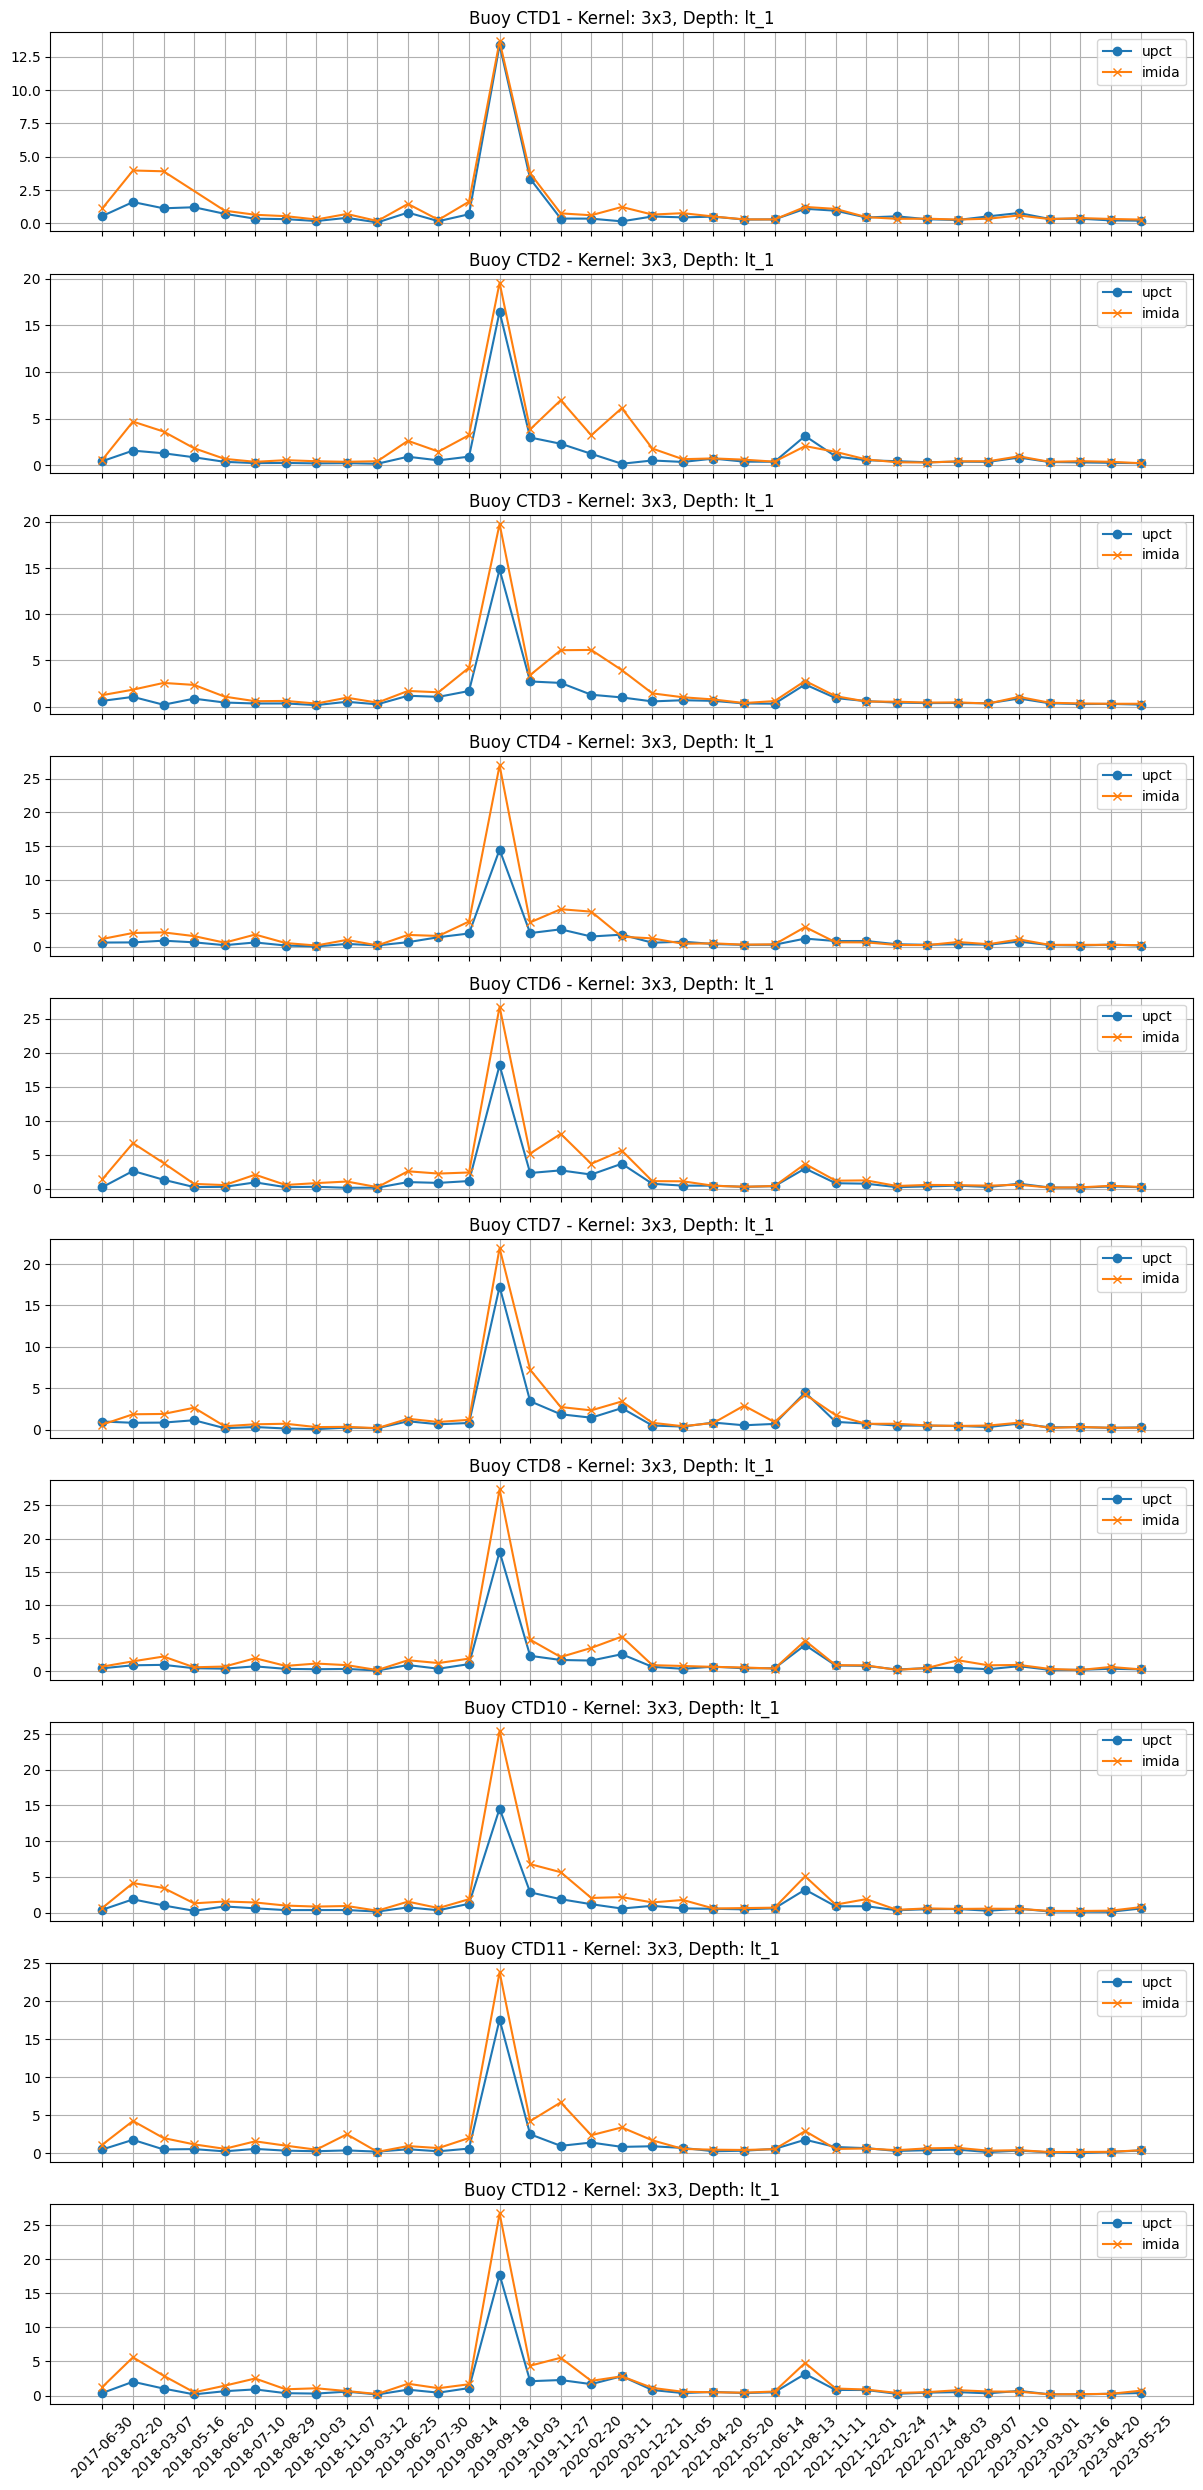

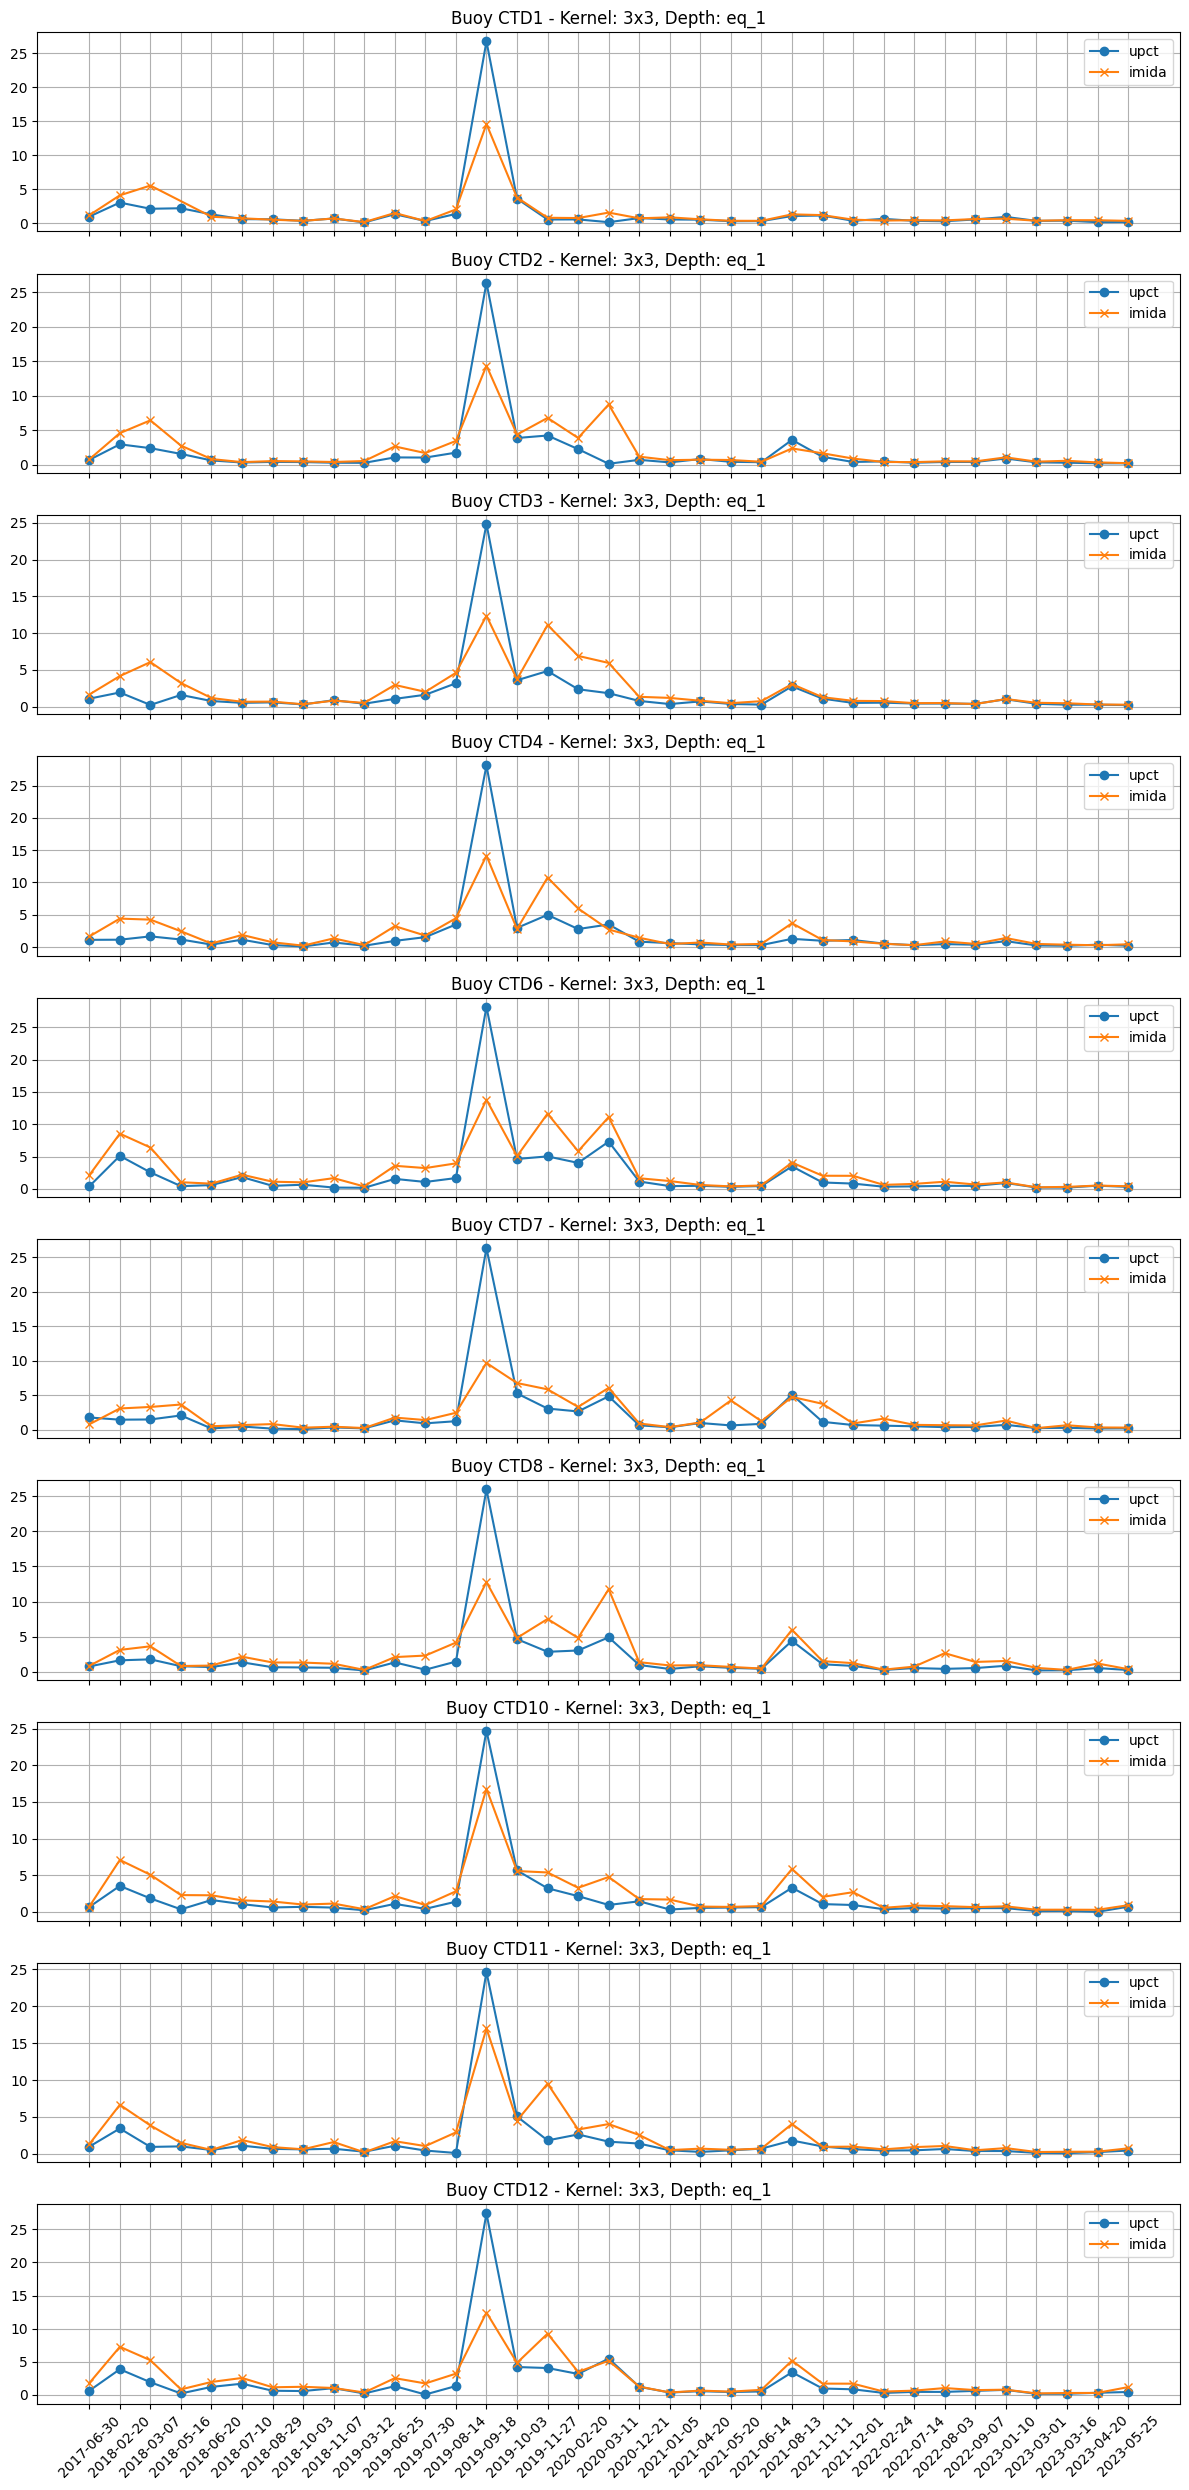

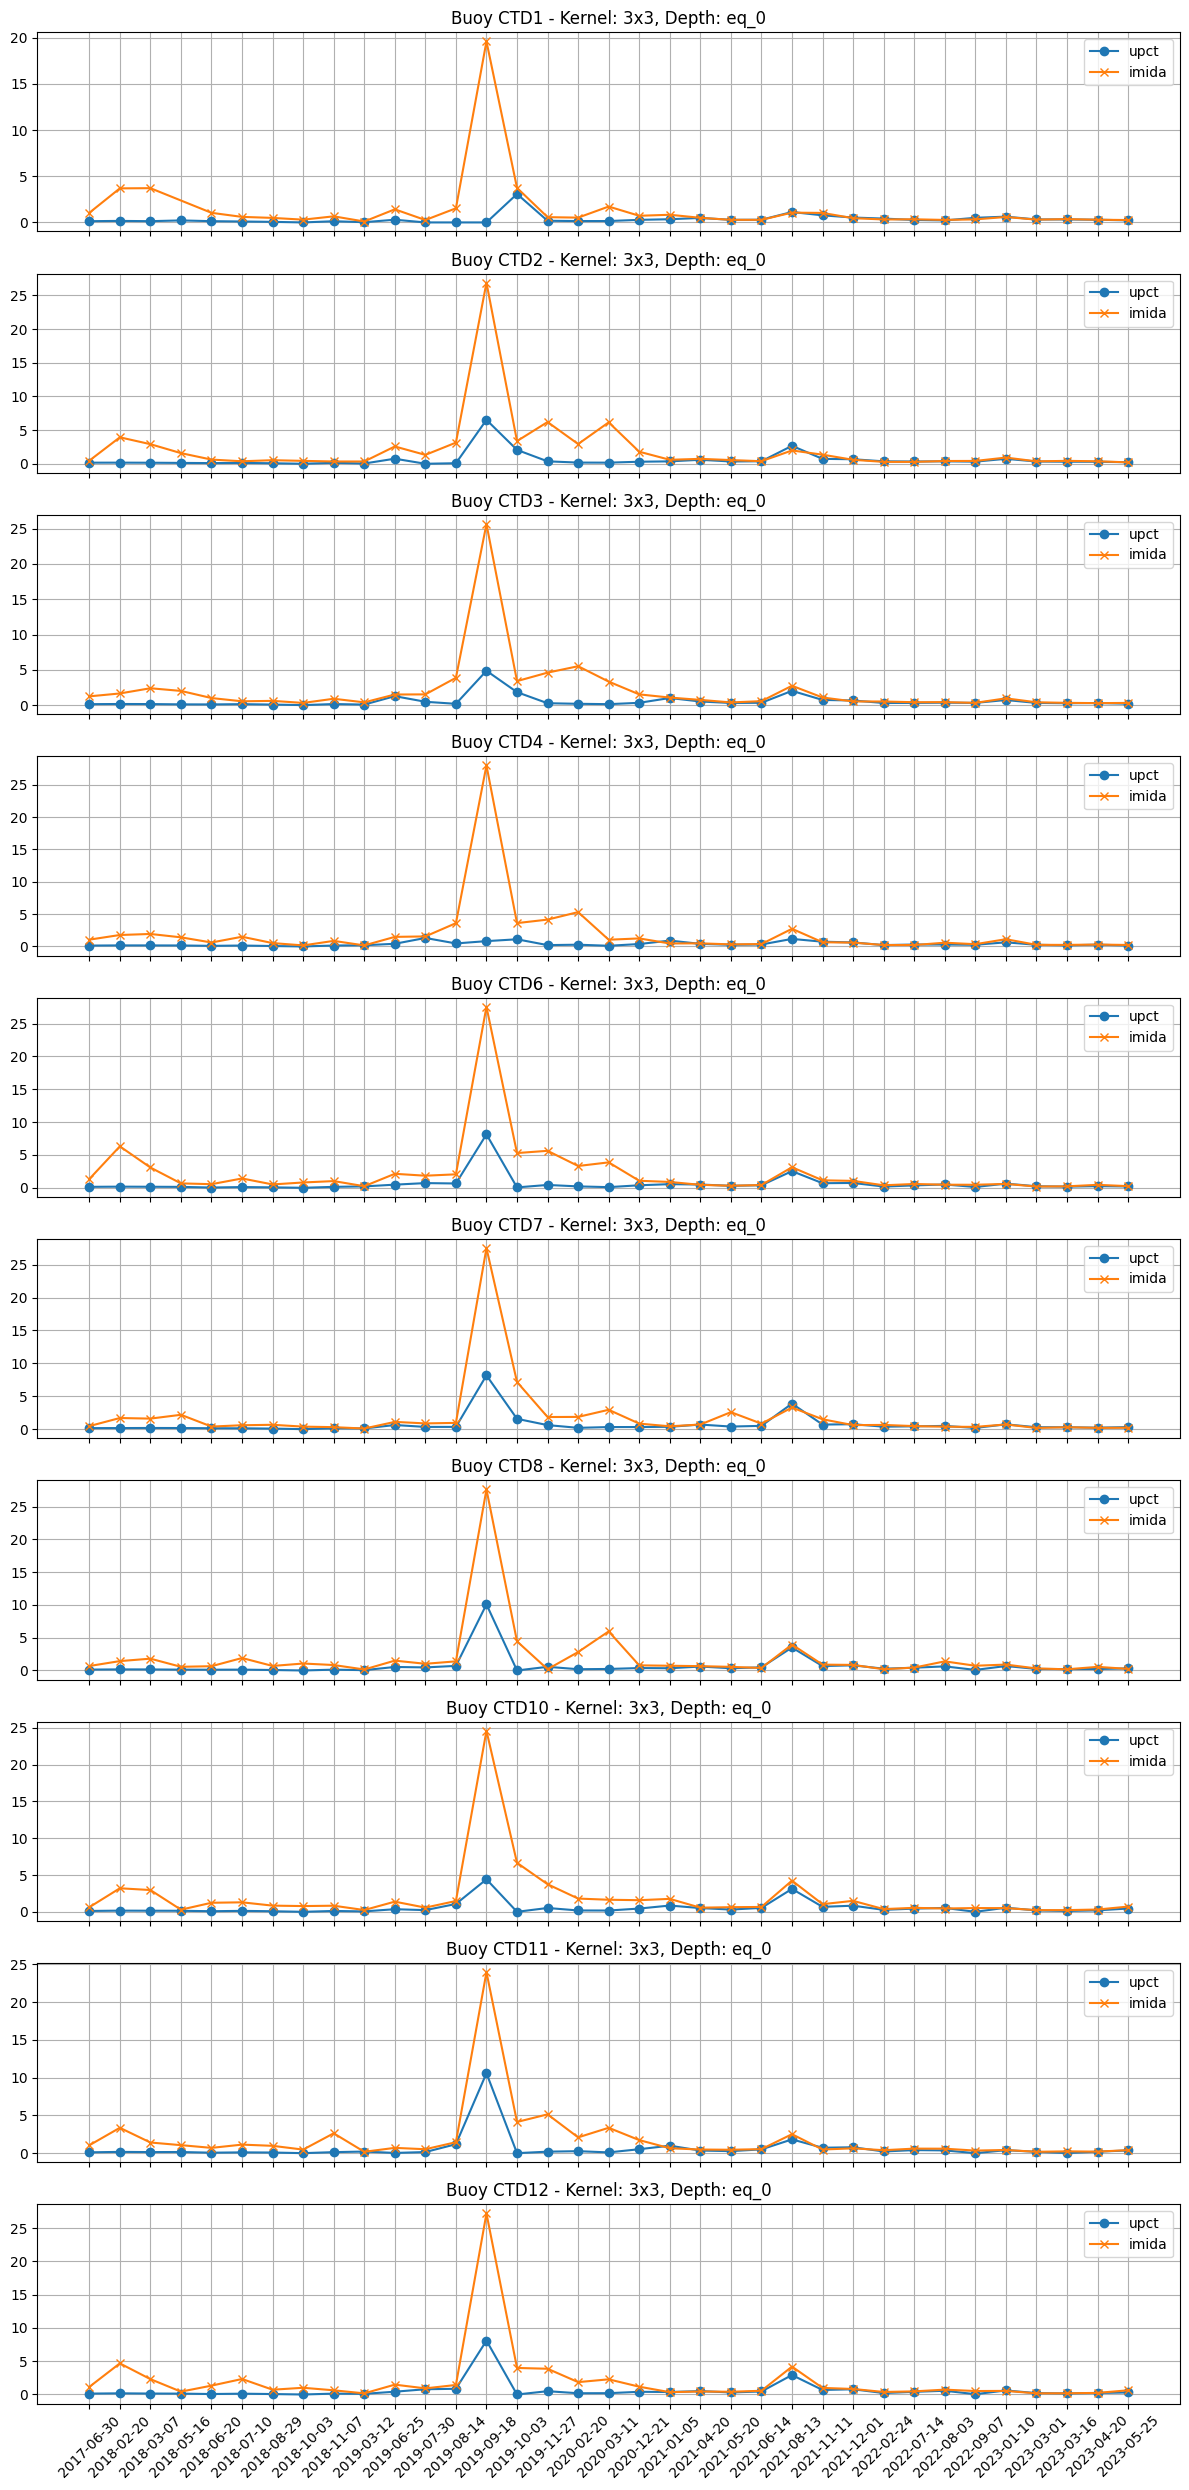

In [39]:
for (kernel, profundidad), tipos in comparables.items():

    if (kernel, profundidad) not in subconjunto:
        continue 

    df_upct = tipos['upct']
    df_imida = tipos['imida']


    if df_upct is not None and df_imida is not None:
        fechas_comunes = set(df_upct['Date']).intersection(df_imida['Date'])
        df_upct_filtrado = df_upct[df_upct['Date'].isin(fechas_comunes)]
        df_imida_filtrado = df_imida[df_imida['Date'].isin(fechas_comunes)]

        # Suponiendo que hay varias 'Buoy', se puede hacer una subfigura por boya
        buoys = df_upct_filtrado['Buoy'].unique()
        fig, axes = plt.subplots(len(buoys), 1, figsize=(12, 2.5 * len(buoys)), sharex=True)

        if len(buoys) == 1:
            axes = [axes]  # Asegura que sea iterable

        for i, buoy in enumerate(buoys):
            upct_buoy = df_upct_filtrado[df_upct_filtrado['Buoy'] == buoy]
            imida_buoy = df_imida_filtrado[df_imida_filtrado['Buoy'] == buoy]

            axes[i].plot(upct_buoy['Date'], upct_buoy['Chl'], label='upct', marker='o')
            axes[i].plot(imida_buoy['Date'], imida_buoy['Chl'], label='imida', marker='x')
            axes[i].set_title(f"Buoy {buoy} - Kernel: {kernel}, Depth: {profundidad}")
            axes[i].legend()
            axes[i].grid(True)
            axes[i].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()


In [7]:
dfs["c2x-nets_1x1_upct_depth_eq_0"]

,Date,Buoy,Latitude,Longitude,rhow_B1,rhow_B2,rhow_B3,rhow_B4,rhow_B5,rhow_B6,...,rhow_B8,rhown_B1,rhown_B2,rhown_B3,rhown_B4,rhown_B5,rhown_B6,Band_15,Band_16,Chl
0,2017-06-30,CTD1,4187246,695025,0.017563,0.029990,0.048420,0.014543,0.010372,0.002755,...,0.001025,0.017399,0.029982,0.048474,0.014503,0.010427,0.002653,0.228823,-0.000000e+00,0.135
1,2017-06-30,CTD2,4181518,693105,0.004140,0.010239,0.015845,0.003232,0.001904,0.000497,...,0.000191,0.004115,0.010528,0.015874,0.003174,0.002011,0.000484,0.000031,-0.000000e+00,0.163
2,2017-06-30,CTD3,4181698,695238,0.027345,0.035083,0.045390,0.014856,0.011023,0.002955,...,0.001075,0.026844,0.035120,0.045748,0.014751,0.010722,0.002801,0.299743,-0.000000e+00,0.135
3,2017-06-30,CTD4,4180266,698264,0.016332,0.026202,0.042141,0.014357,0.010686,0.002870,...,0.001069,0.016146,0.026217,0.042271,0.014329,0.010611,0.002783,0.292377,-0.000000e+00,0.136
4,2017-06-30,CTD6,4176009,695829,0.026543,0.036842,0.052834,0.016880,0.012582,0.003304,...,0.001195,0.026217,0.036822,0.053231,0.016835,0.012265,0.003153,0.341798,-0.000000e+00,0.145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,2023-05-25,CTD7,4176724,690397,0.005132,0.012160,0.015382,0.002264,0.001297,0.000327,...,0.000123,0.005064,0.012532,0.015453,0.002209,0.001352,0.000318,0.000462,-2.870000e-42,0.308
376,2023-05-25,CTD8,4174178,693048,0.006596,0.013887,0.016587,0.002643,0.001553,0.000404,...,0.000155,0.006541,0.014142,0.016591,0.002600,0.001639,0.000395,0.011636,-0.000000e+00,0.314
377,2023-05-25,CTD10,4170388,695646,0.002386,0.006297,0.008161,0.000962,0.000515,0.000129,...,0.000047,0.002371,0.006617,0.008326,0.000918,0.000533,0.000123,0.000099,-2.870000e-42,0.448
378,2023-05-25,CTD11,4169609,700351,0.007384,0.015141,0.019847,0.003599,0.002178,0.000580,...,0.000224,0.007339,0.015337,0.019836,0.003560,0.002317,0.000569,0.029142,-0.000000e+00,0.360


In [34]:
pares = []
for key1 in sorted(dataframes_boyas_imida.keys(), key=lambda x: int(re.search(r'CTD-E(\d+)', x).group(1))):
    num = re.search(r'CTD-E(\d+)', key1).group(1)
    if num == '5' or num == '9':
        continue
    key2 = f"CTD{num}_Clorofila"
    if key2 in dataframes_boyas_upct:
        pares.append((key1, key2))

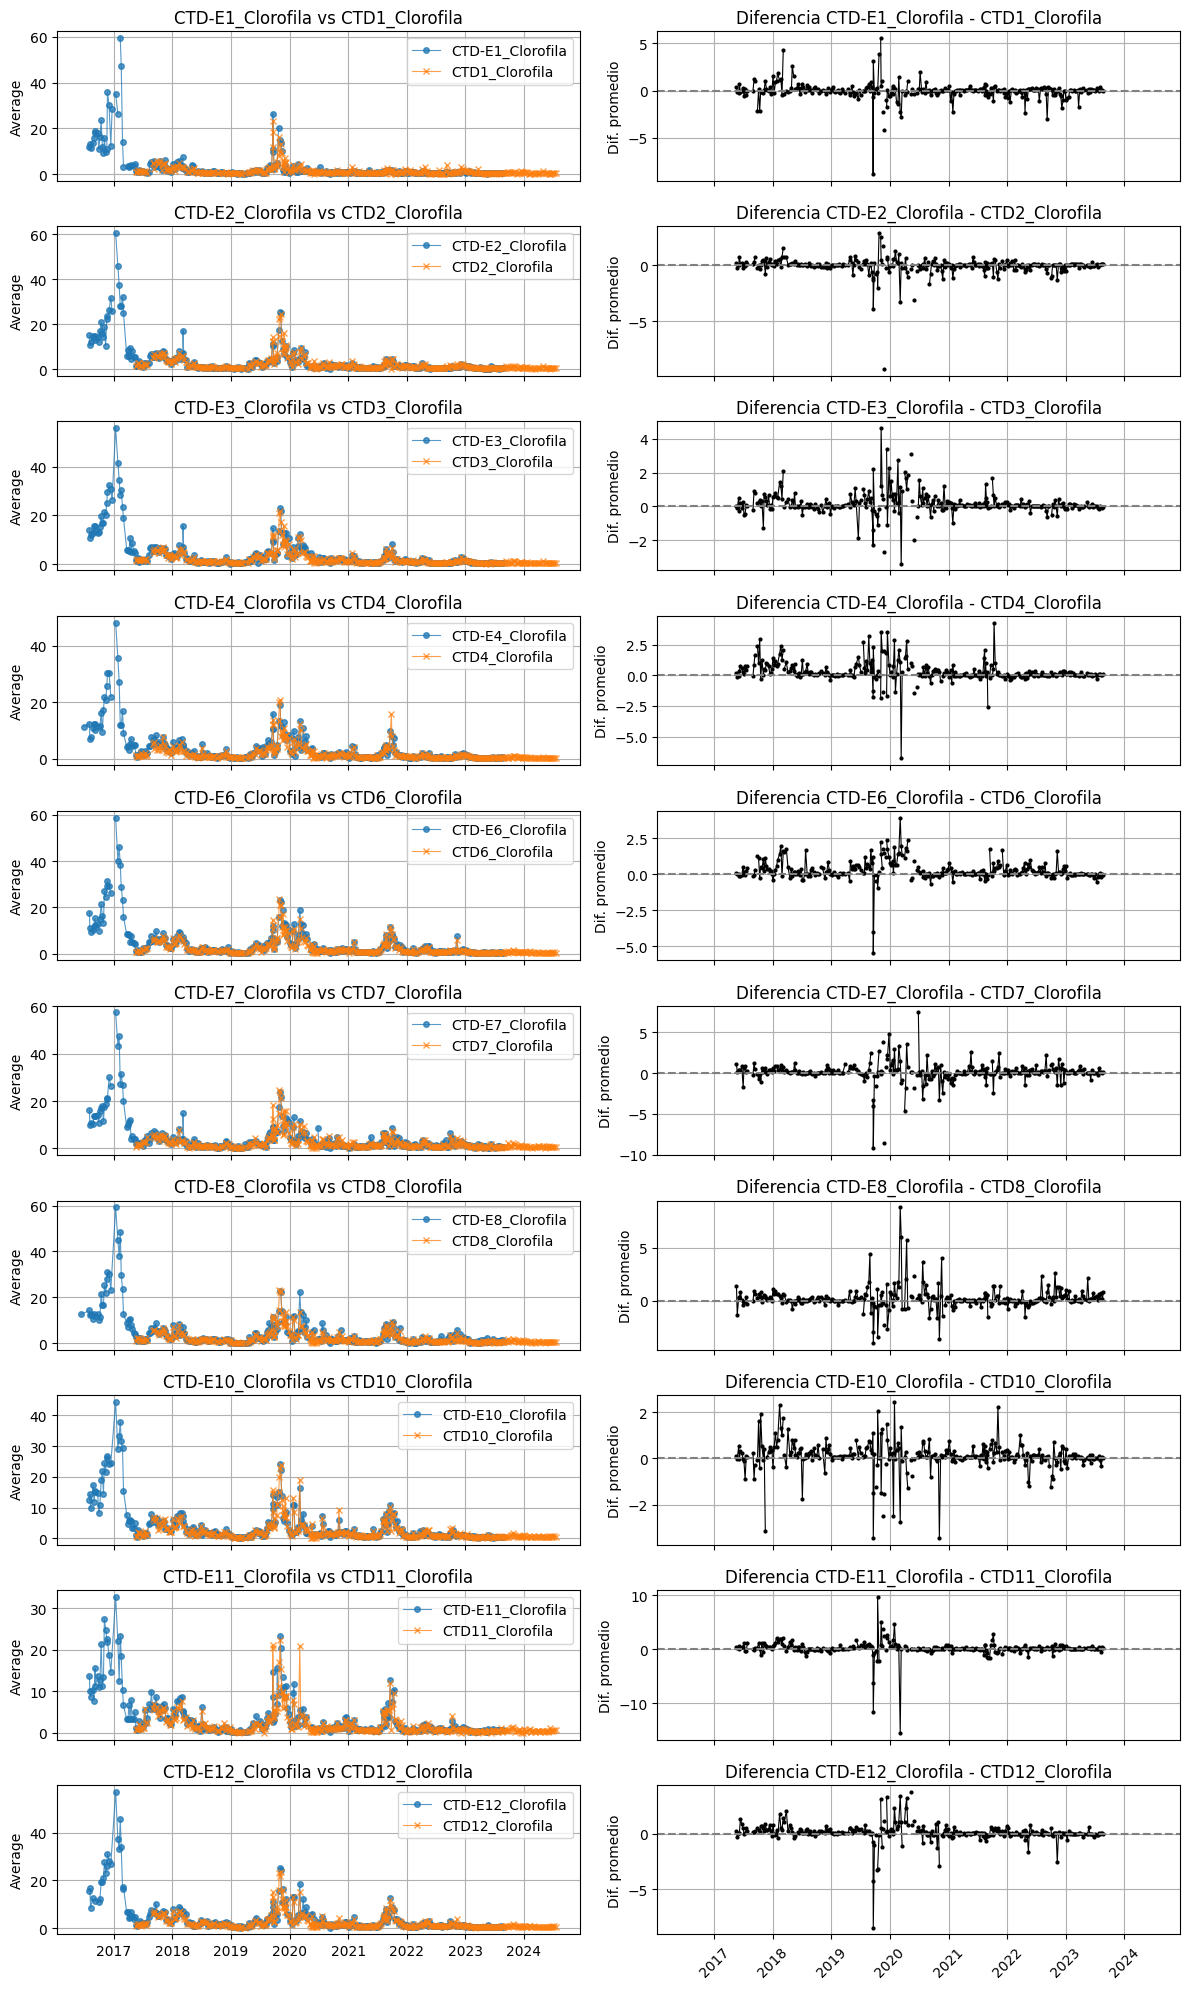

In [35]:
# Crear subplots
fig, axes = plt.subplots(nrows=len(pares), ncols=2, figsize=(12, len(pares)*2), sharex=True)

# Si solo hay un subplot, `axes` no es una lista
if len(pares) == 1:
    axes = [axes]  # Asegurar que axes es iterable

for i, (k1, k2) in enumerate(pares):
    df1 = dataframes_boyas_imida[k1][['fecha', 'Average']].copy()
    df2 = dataframes_boyas_upct[k2][['Date', 'Average']].copy()

    # Convertir a datetime
    df1['fecha'] = pd.to_datetime(df1['fecha'])
    df2['Date'] = pd.to_datetime(df2['Date'])

    # Rango común de fechas (unión)
    fechas_comunes = pd.Series(df1['fecha'].tolist() + df2['Date'].tolist()).drop_duplicates().sort_values()

    # Reindexar
    df1.set_index('fecha', inplace=True)
    df2.set_index('Date', inplace=True)
    df1 = df1.reindex(fechas_comunes)
    df2 = df2.reindex(fechas_comunes)

    # Columna 1: comparación
    ax_cmp = axes[i][0] if len(pares) > 1 else axes[0]
    ax_cmp.plot(fechas_comunes, df1['Average'], label=k1, marker='o', markersize=4, linewidth=0.8, alpha=0.75)
    ax_cmp.plot(fechas_comunes, df2['Average'], label=k2, marker='x', markersize=4, linewidth=0.8, alpha=0.75)
    ax_cmp.set_title(f'{k1} vs {k2}')
    ax_cmp.set_ylabel('Average')
    ax_cmp.legend()
    ax_cmp.grid(True)

    # Columna 2: diferencia
    ax_diff = axes[i][1] if len(pares) > 1 else axes[1]
    diferencia = df1['Average'] - df2['Average']
    ax_diff.plot(fechas_comunes, diferencia, label='Diferencia', color='black', marker='.', markersize=4, linewidth=0.8)
    ax_diff.axhline(0, color='gray', linestyle='--')
    ax_diff.set_title(f'Diferencia {k1} - {k2}')
    ax_diff.set_ylabel('Dif. promedio')
    ax_diff.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()